In [1]:
import os
import sys

project_root = os.path.abspath("..")

if project_root not in sys.path:
    sys.path.append(project_root)

print(project_root)

c:\Users\arbaa\Desktop\ecg-fatigue-detection


In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from src.config import (
    WINDOW_SIZE,
    STEP_SIZE,
    SAMPLING_RATE,
)

from src.preprocessing import (
    load_subject,
    extract_ecg,
    extract_labels,
)

from src.dataset import (
    create_windows,
    assign_window_labels,
    build_feature_dataset,
)

from src.train import (
    load_feature_dataset,
    split_dataset,
    train_random_forest,
    save_model,
)

from src.evaluate import (
    evaluate_model,
    print_classification_report,
    plot_confusion_matrix,
)

print("Modules imported successfully!")

Modules imported successfully!


In [3]:
dataset_path = r"C:\Users\arbaa\Desktop\ecg-fatigue-detection\data\raw\WESAD"

subject = load_subject(dataset_path, "S2")

print(subject.keys())

dict_keys(['signal', 'label', 'subject'])


In [4]:
ecg = extract_ecg(subject)
labels = extract_labels(subject)

print(ecg.shape)
print(labels.shape)

(4255300, 1)
(4255300,)


In [5]:
from src.dataset import create_windows, assign_window_labels
from src.config import WINDOW_SIZE, STEP_SIZE

windows = create_windows(
    ecg,
    WINDOW_SIZE,
    STEP_SIZE,
)

window_labels = assign_window_labels(
    labels,
    WINDOW_SIZE,
    STEP_SIZE,
)

print(len(windows))
print(len(window_labels))

404
404


In [6]:
from src.dataset import build_feature_dataset

feature_df = build_feature_dataset(
    windows,
    window_labels,
)

print(feature_df.shape)
feature_df.head()

(404, 8)


,Mean_RR,Mean_HR,SDNN,RMSSD,Min_RR,Max_RR,Median_RR,Label
0,837.268908,71.661565,77.136140,54.333540,700.000000,985.714286,838.571429,0
1,792.277992,75.730994,83.551517,35.459408,667.142857,944.285714,792.857143,0
2,743.333333,80.717489,63.248311,28.902220,634.285714,884.285714,742.857143,0
3,758.721805,79.080369,51.727192,39.789851,634.285714,878.571429,757.142857,0
4,767.490347,78.176879,42.491887,36.946980,648.571429,855.714286,765.714286,0


In [7]:
from src.train import (
    load_feature_dataset,
    split_dataset,
    train_random_forest,
)

X, y = load_feature_dataset(feature_df)

print(X.shape)
print(y.shape)

(404, 7)
(404,)


In [8]:
X_train, X_test, y_train, y_test = split_dataset(X, y)

print(X_train.shape)
print(X_test.shape)

(323, 7)
(81, 7)


In [9]:
model = train_random_forest(
    X_train,
    y_train,
)

print(model)

RandomForestClassifier(random_state=42)


{'Accuracy': 0.5679012345679012, 'Precision': 0.5153115917004805, 'Recall': 0.5679012345679012, 'F1 Score': 0.5362451592985794}
              precision    recall  f1-score   support

           0       0.65      0.76      0.70        41
           1       0.62      0.53      0.57        15
           2       0.55      0.75      0.63         8
           3       0.00      0.00      0.00         5
           4       0.17      0.10      0.12        10
           6       0.00      0.00      0.00         1
           7       0.00      0.00      0.00         1

    accuracy                           0.57        81
   macro avg       0.28      0.31      0.29        81
weighted avg       0.52      0.57      0.54        81



c:\Users\arbaa\Desktop\ecg-fatigue-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\arbaa\Desktop\ecg-fatigue-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\arbaa\Desktop\ecg-fatigue-detection\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

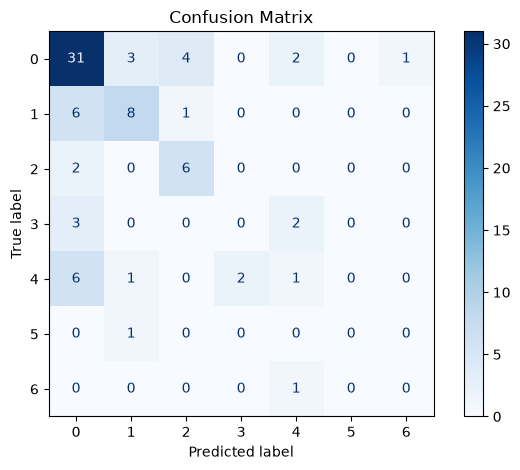

In [10]:
from src.evaluate import (
    evaluate_model,
    print_classification_report,
    plot_confusion_matrix,
)

metrics = evaluate_model(
    model,
    X_test,
    y_test,
)

print(metrics)

print_classification_report(
    model,
    X_test,
    y_test,
)

plot_confusion_matrix(
    model,
    X_test,
    y_test,
)

In [11]:
from pathlib import Path

print(Path)
print(type(Path))

<class 'pathlib.Path'>
<class 'type'>


In [ ]:
from src.train import save_model
save_model(model)

Model saved to: C:\Users\arbaa\Desktop\ecg-fatigue-detection\models\random_forest.pkl


: 